## Use the file data.csv which contains 169 rows and 4 columns.
## 1. Convert this file into pandas Data Frame and Display basic statistics like mean, std, quartiles, etc. for this data frame.
## 2. Print first and last 5 rows. Also print the shape of the dataframe.
## 3. Create a correlation table for the data frame and comment about what kind of correlation is there between Duration and Calories?
## 4. Find whether there any null or NA values, drop all such rows if found in the data frame and print the shape of the data frame after dropping.
## 5. Prepare a scatter matrix for the following data frame.
## 6. Prepare a parallel coordinates for Duration v/s Pulse, Maxpulse and Calories (all 3 other columns).
## 7. Prepare a cross-tabulation for Duration v/s Pulse.
## 8. Do Maxpulse have any outliers? Find using function.

In [28]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix,parallel_coordinates

In [7]:
df = pd.read_csv('data.csv')
df.describe()

,Duration,Pulse,Maxpulse,Calories
count,169.000000,169.000000,169.000000,164.000000
mean,63.846154,107.461538,134.047337,375.790244
std,42.299949,14.510259,16.450434,266.379919
min,15.000000,80.000000,100.000000,50.300000
25%,45.000000,100.000000,124.000000,250.925000
50%,60.000000,105.000000,131.000000,318.600000
75%,60.000000,111.000000,141.000000,387.600000
max,300.000000,159.000000,184.000000,1860.400000


In [18]:
print(df.head())
print("======================")
print(df.tail())
print("======================")
print(df.shape)

   Duration  Pulse  Maxpulse  Calories
0        60    110       130     409.1
1        60    117       145     479.0
2        60    103       135     340.0
3        45    109       175     282.4
4        45    117       148     406.0
     Duration  Pulse  Maxpulse  Calories
164        60    105       140     290.8
165        60    110       145     300.0
166        60    115       145     310.2
167        75    120       150     320.4
168        75    125       150     330.4
(169, 4)


In [19]:
print(df.corr(numeric_only=True))

          Duration     Pulse  Maxpulse  Calories
Duration  1.000000 -0.155408  0.009403  0.922717
Pulse    -0.155408  1.000000  0.786535  0.025121
Maxpulse  0.009403  0.786535  1.000000  0.203813
Calories  0.922717  0.025121  0.203813  1.000000


In [21]:
print(df[['Duration','Calories']].corr())

          Duration  Calories
Duration  1.000000  0.922717
Calories  0.922717  1.000000


In [27]:
print(df.isnull().sum())
df = df.dropna()
print("shape after droping")
print(df.shape)

Duration    0
Pulse       0
Maxpulse    0
Calories    0
dtype: int64
shape after droping
(164, 4)


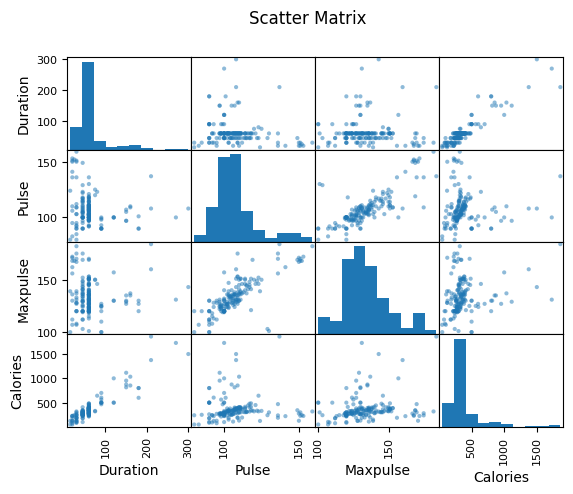

In [31]:
scatter_matrix(df)
plt.suptitle("Scatter Matrix")
plt.show()

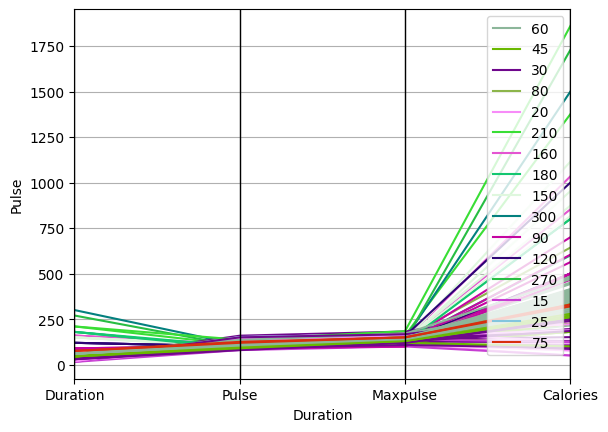

In [32]:
pd.plotting.parallel_coordinates(df,"Duration",cols=["Duration","Pulse","Maxpulse","Calories"])
plt.xlabel("Duration")
plt.ylabel("Pulse")
plt.show()

In [35]:
pd.crosstab(df["Duration"],df['Pulse'])

Pulse,80,83,85,90,92,93,95,97,98,99,...,130,136,137,141,149,150,151,152,153,159
Duration,,,,,,,,,,,,,,,,,,,,,
15,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
20,0,1,0,0,0,0,1,0,0,0,...,0,1,0,1,0,1,1,0,1,0
25,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
30,1,0,1,2,1,1,1,0,0,0,...,0,1,0,0,0,1,1,0,0,1
45,0,0,0,3,0,0,1,1,0,0,...,0,0,0,0,1,0,0,0,0,0
60,0,0,0,0,2,1,0,3,5,1,...,1,1,0,0,0,0,0,0,0,0
75,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
80,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
90,0,0,0,4,0,1,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0


In [42]:
def outlier(ds,col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1 
    low = q1 - iqr*1.5
    upp = q3 + iqr*1.5
    out = df[(df[col] < low) | (df[col] > upp)]
    return out

In [43]:
outlier(df,'Maxpulse')

,Duration,Pulse,Maxpulse,Calories
3,45,109,175,282.4
54,30,136,175,238.0
58,20,153,172,226.4
80,30,159,182,319.2
109,210,137,184,1860.4


Use the above code to generate sample data and then create the following:
1. Using the sample data for years and sales, create an area plot to visualize the trend in sales over the years. What insights can you gather from this area plot (answer as a comment)?
2. Utilizing the data in category1, category2, and category3, create a box plot using Matplotlib. How does the box plot reveal the distribution and potential outliers in these three categories
(answer as a comment)?
3. Using the generated data for x and y, create a scatter plot with Matplotlib. What patterns or correlations, if any, can you observe between the x and y values in this scatter plot (answer as a
comment)?
4. Employ the sample data to create a heatmap using Seaborn. What does the heatmap convey about the relationships between the values in the data matrix (answer as a comment)?
5. With the height and weight data, generate a regression plot using Seaborn. What conclusions can be drawn about the relationship between height and weight from this plot (answer as a
comment)?

In [44]:
import random
# Sample data for area plot
years = [2010, 2011, 2012, 2013, 2014]
sales = [200, 300, 450, 350, 500]
# Sample data for box plot
category1 = [random.randint(1, 50) for _ in range(50)]
category2 = [random.randint(25, 75) for _ in range(50)]
category3 = [random.randint(50, 100) for _ in range(50)]
# Sample data for scatter plot
x = [random.uniform(0, 10) for _ in range(50)]
y = [random.uniform(0, 10) for _ in range(50)]
# Sample data for heatmap
import numpy as np
data = np.random.rand(5, 5)
# Sample data for regression plot
height = [160, 165, 170, 175, 180, 185]
weight = [60, 65, 70, 75, 80, 85]


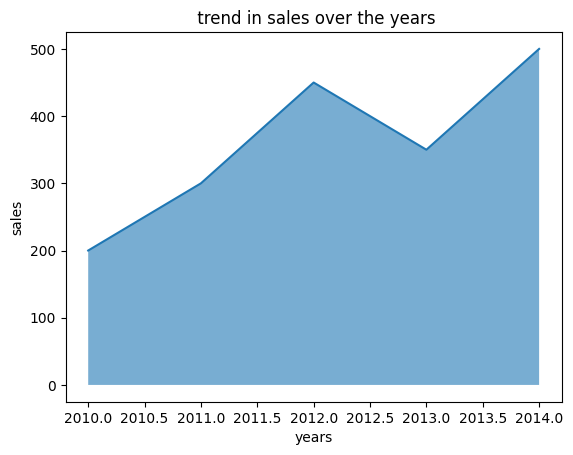

In [51]:
import matplotlib.pyplot as plt

plt.plot(years,sales)
plt.fill_between(years,sales,alpha=0.6)
plt.title(" trend in sales over the years")
plt.xlabel("years")
plt.ylabel("sales")
plt.show()

C:\Users\mistr\AppData\Local\Temp\ipykernel_33132\1787983886.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([category1,category2,category3],labels=['Category 1','Category 2','Category 3'])


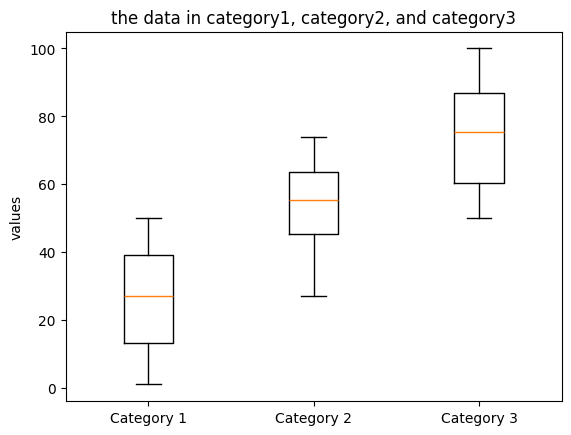

In [57]:
plt.boxplot([category1,category2,category3],labels=['Category 1','Category 2','Category 3'])
plt.title("the data in category1, category2, and category3")
plt.ylabel("values")
plt.show()

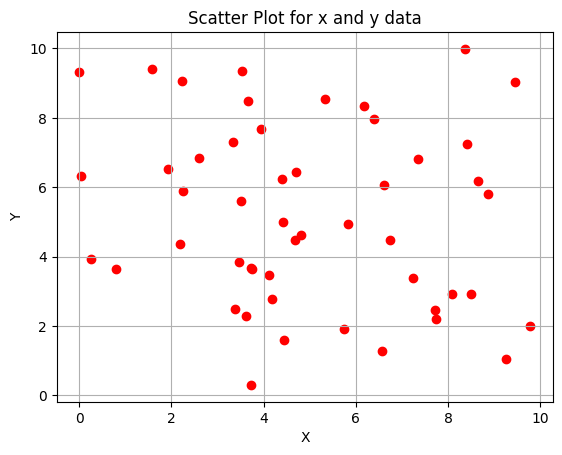

In [62]:
plt.scatter(x,y,color='red')
plt.title("Scatter Plot for x and y data")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.show()

<Axes: >

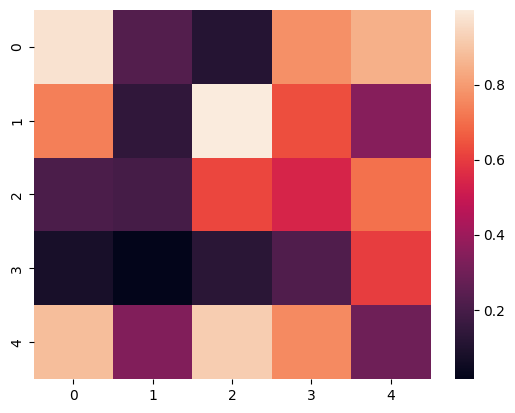

In [63]:
import seaborn as sns
sns.heatmap(data)

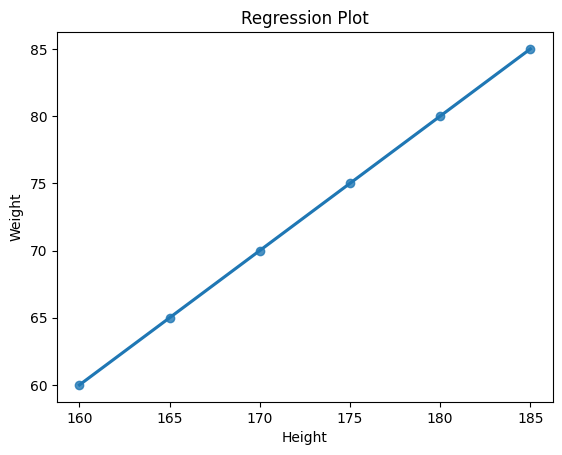

In [67]:
sns.regplot(x=height,y=weight)
plt.title("Regression Plot")
plt.xlabel("Height")
plt.ylabel("Weight")
plt.show()

Write a program to create a Model using linear regression to predict the charges of insurance using the csv file provided named “insurance.csv”. Do the required process in the data before making a model. Find predicted values, co-efficients, intercept and mean squared error.

In [80]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

df = pd.read_csv("insurance.csv")
df = pd.get_dummies(df,drop_first=True)
x = df.drop("charges",axis=1)
y = df['charges'] 
x_test,x_train,y_test,y_train = train_test_split(x,y,random_state=42,test_size=0.2)
model = LinearRegression()
model.fit(x_train,y_train)

y_pred = model.predict(x_test)
mse = mean_squared_error(y_pred,y_test)
print("mean_squared_error",mse)
print("Predicted Values",y_pred)
print(model.coef_)
print(model.intercept_)

mean_squared_error 38291133.01290261
Predicted Values [ 7660.17551528  8444.98866399  7287.92976349 ... 11054.4277859
 38731.50406689 10225.27515539]
[  252.57750627   356.75979697   730.57221125  -473.9430735
 24802.888122    -434.33975216 -2612.59672223 -1757.11015238]
-12102.552393174263
